# Learn a shell law with a neural network

When you don't know the form of a constitutive law, you can learn it from data. In this example, a small neural network takes the place of the surface tension $\sigma(R)$ of a lipid shell, and `fit_parameters` trains its weights on radius curves recorded at six driving pressures. The network recovers the buckling, elastic, and ruptured regimes of the Marmottant law without being told that they exist.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from jbubble import SaveSpec, fit_parameters, run_simulation
from jbubble.bubble.eom import KellerMiksis
from jbubble.bubble.gas import PolytropicGas
from jbubble.bubble.medium import NewtonianMedium
from jbubble.bubble.property import NeuralProperty
from jbubble.bubble.shell import LipidShell, MarmottantSurfaceTension
from jbubble.bubble.state import BubbleState
from jbubble.metrics import normalised_mse_radius
from jbubble.pulse import HannEnvelope, ToneBurst
from jbubble.pulse.shapes import Sine

plt.style.use("jbubble.style.light")

# Set JBUBBLE_QUICK=1 for a fast, coarse run (used by CI).
QUICK = os.environ.get("JBUBBLE_QUICK") == "1"

# Training steps. About 1000 steps take about a minute on a laptop CPU and
# recover the law to within a few mN/m. About 3000 steps tighten the fit
# further, roughly halving the error in sigma(R).
N_STEPS = 100 if QUICK else 1000

## Make stand-in measurements

The stand-in bubble is a 2 µm SF6 bubble with a lipid shell that follows the piecewise [`MarmottantSurfaceTension`](https://imperial-nsb.github.io/jbubble/api/bubble/#jbubble.bubble.shell.MarmottantSurfaceTension) law, driven by five-cycle, Hann-windowed 1 MHz tone bursts from 30 to 180 kPa. The low pressures probe the shell near its equilibrium radius, and the high pressures drive it through buckling and rupture. The shell viscosity and every other model input are known; only $\sigma(R)$ is unknown.

The recordings span R/R0 = 0.48 to 1.76


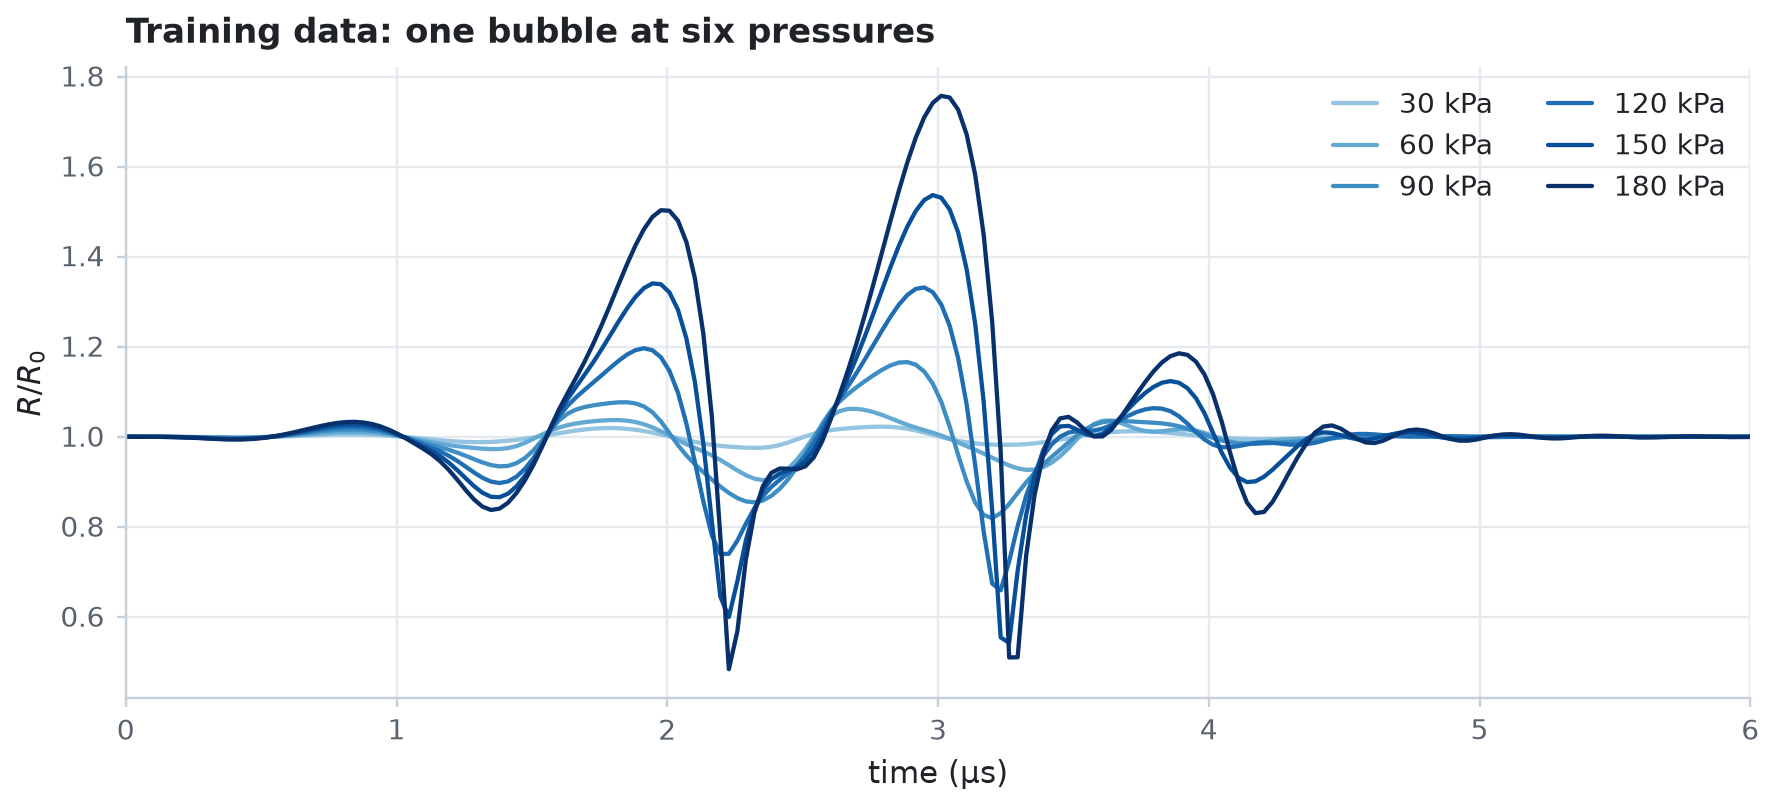

In [2]:
R0 = 2e-6  # equilibrium radius [m]
KAPPA_S = 7.5e-9  # shell dilatational viscosity [N s/m]
SIGMA_MAX = 0.072  # surface tension of water, the upper bound on sigma [N/m]
PRESSURES = [30e3, 60e3, 90e3, 120e3, 150e3, 180e3]  # [Pa]
SAVE_SPEC = SaveSpec(256)
T_MAX = 8e-6  # [s]


def make_eom(sigma):
    return KellerMiksis(
        gas=PolytropicGas(gamma=1.095),
        shell=LipidShell(sigma=sigma, kappa_s=KAPPA_S),
        medium=NewtonianMedium(mu=1e-3, rho_L=998.0, c_L=1500.0),
        R0=R0,
        P_amb=101325.0,
    )


def make_pulse(pressure):
    return ToneBurst(
        freq=1e6, pressure=pressure, shape=Sine(), cycle_num=5, envelope=HannEnvelope()
    )


true_sigma = MarmottantSurfaceTension(
    R_buckle_ratio=0.98058, chi=0.5, sigma_rupture=SIGMA_MAX
)
recordings = [
    run_simulation(
        make_eom(true_sigma), make_pulse(p), save_spec=SAVE_SPEC, t_max=T_MAX
    )
    for p in PRESSURES
]
conditions = [
    {"pressure": p, "radius": r.radius}
    for p, r in zip(PRESSURES, recordings, strict=True)
]
ts_us = np.asarray(recordings[0].ts) * 1e6  # [µs]
# The range of R/R0 that the recordings cover. The data say nothing about
# sigma outside it.
x_lo = min(float(c["radius"].min()) for c in conditions) / R0
x_hi = max(float(c["radius"].max()) for c in conditions) / R0
print(f"The recordings span R/R0 = {x_lo:.2f} to {x_hi:.2f}")

shades = plt.get_cmap("Blues")(np.linspace(0.4, 1.0, len(PRESSURES)))
fig, ax = plt.subplots(figsize=(8, 3.6))
for condition, colour in zip(conditions, shades, strict=True):
    label = f"{condition['pressure'] / 1e3:.0f} kPa"
    ax.plot(ts_us, condition["radius"] / R0, color=colour, lw=1.4, label=label)
ax.set_xlim(0, 6)  # the bubble has rung down by 6 µs
ax.set_xlabel("time (µs)")
ax.set_ylabel(r"$R/R_0$")
ax.set_title("Training data: one bubble at six pressures")
ax.legend(loc="upper right", ncols=2)
plt.show()

## Put a network in the shell

[`NeuralProperty`](https://imperial-nsb.github.io/jbubble/api/bubble/#jbubble.bubble.property.NeuralProperty) wraps any Equinox network as a [`Property`](https://imperial-nsb.github.io/jbubble/api/bubble/#jbubble.bubble.property.Property): it passes the normalised radius $R/R_0$ to the network and returns its output. Any model input that accepts a `Property` accepts it, here the shell's surface tension.

The network's `final_activation` bounds its output to $(0, \sigma_\text{max})$ with a scaled sigmoid. The bound encodes what you know about the physics: a surface tension is never negative and never exceeds that of clean water. It also keeps every law that the optimiser tries during training physical, so the solver never meets a negative surface tension.

In [3]:
def bounded_sigma(x):
    return SIGMA_MAX * jax.nn.sigmoid(x)


sigma0 = NeuralProperty(
    net=eqx.nn.MLP(
        in_size=1,
        out_size=1,
        width_size=8,
        depth=2,
        activation=jnp.tanh,
        final_activation=bounded_sigma,
        key=jax.random.PRNGKey(0),
    )
)
n_weights = sum(w.size for w in jax.tree.leaves(eqx.filter(sigma0, eqx.is_array)))
print(f"The network has {n_weights} weights")

The network has 97 weights


## Train it with `fit_parameters`

`params0` can be any Equinox module: `fit_parameters` fits every floating-point array inside it, here the network's weights, and passes the module to `make_model`. Each recording is one entry of `conditions`, and the six recordings run in parallel with `jax.vmap`. A cosine-decay learning rate lets the fit settle at the end of training.

`step_callback` keeps a few snapshots of the network, so that you can watch the law take shape.

In [4]:
def make_model(sigma, condition):
    return make_eom(sigma), make_pulse(condition["pressure"])


def loss_fn(result, condition):
    return normalised_mse_radius(result.radius, condition["radius"], R0)


snapshot_steps = (0, N_STEPS // 5, N_STEPS)
snapshots = {}


def keep_snapshots(step, sigma, loss):
    if step in snapshot_steps:
        snapshots[step] = sigma


start = time.perf_counter()
fit = fit_parameters(
    make_model,
    sigma0,
    conditions=conditions,
    loss_fn=loss_fn,
    optimizer=optax.adam(optax.cosine_decay_schedule(1e-2, N_STEPS, alpha=0.05)),
    n_steps=N_STEPS,
    save_spec=SAVE_SPEC,
    t_max=T_MAX,
    step_callback=keep_snapshots,
    log_every=N_STEPS // 10,
)
print(f"Training took {time.perf_counter() - start:.0f} s: {fit.message}")

  step    0 / 1000  loss = 1.4629e-02  <97 values in 6 arrays>


  step  100 / 1000  loss = 5.2038e-03  <97 values in 6 arrays>


  step  200 / 1000  loss = 5.1441e-03  <97 values in 6 arrays>


  step  300 / 1000  loss = 5.1256e-03  <97 values in 6 arrays>


  step  400 / 1000  loss = 5.0335e-03  <97 values in 6 arrays>


...

  step  600 / 1000  loss = 6.6689e-05  <97 values in 6 arrays>


  step  700 / 1000  loss = 4.5394e-05  <97 values in 6 arrays>


  step  800 / 1000  loss = 3.6866e-05  <97 values in 6 arrays>


  step  900 / 1000  loss = 3.3039e-05  <97 values in 6 arrays>


  step 1000 / 1000  loss = 3.1047e-05  <97 values in 6 arrays>
Training took 99 s: completed 1000 steps


## Compare the learned law with the truth

A `Property` is a function of the bubble state, so you can evaluate the learned law, and the true one, on any grid of radii.

In [5]:
x = jnp.linspace(0.3, 2.0, 400)


def evaluate(sigma):
    """sigma(R) in mN/m on the grid of R/R0 values."""
    values = jax.vmap(lambda r: sigma(BubbleState(R=r * R0, R0=jnp.asarray(R0))))(x)
    return np.asarray(values) * 1e3


sigma_true = evaluate(true_sigma)
sigma_learned = evaluate(fit.params)
inside = (np.asarray(x) >= x_lo) & (np.asarray(x) <= x_hi)
rmse = np.sqrt(np.mean((sigma_learned - sigma_true)[inside] ** 2))
print(f"Loss {float(fit.loss_history[0]):.2e} -> {float(fit.loss_history[-1]):.2e}")
print(f"RMS error in sigma(R) over the recorded range: {rmse:.1f} mN/m")
learned_r0 = float(fit.params(BubbleState(R=jnp.array(R0), R0=jnp.array(R0)))) * 1e3
true_r0 = float(true_sigma(BubbleState(R=jnp.array(R0), R0=jnp.array(R0)))) * 1e3
print(f"sigma(R0): learned {learned_r0:.1f} mN/m, true {true_r0:.1f} mN/m")

Loss 1.46e-02 -> 3.10e-05
RMS error in sigma(R) over the recorded range: 2.1 mN/m
sigma(R0): learned 19.8 mN/m, true 20.0 mN/m


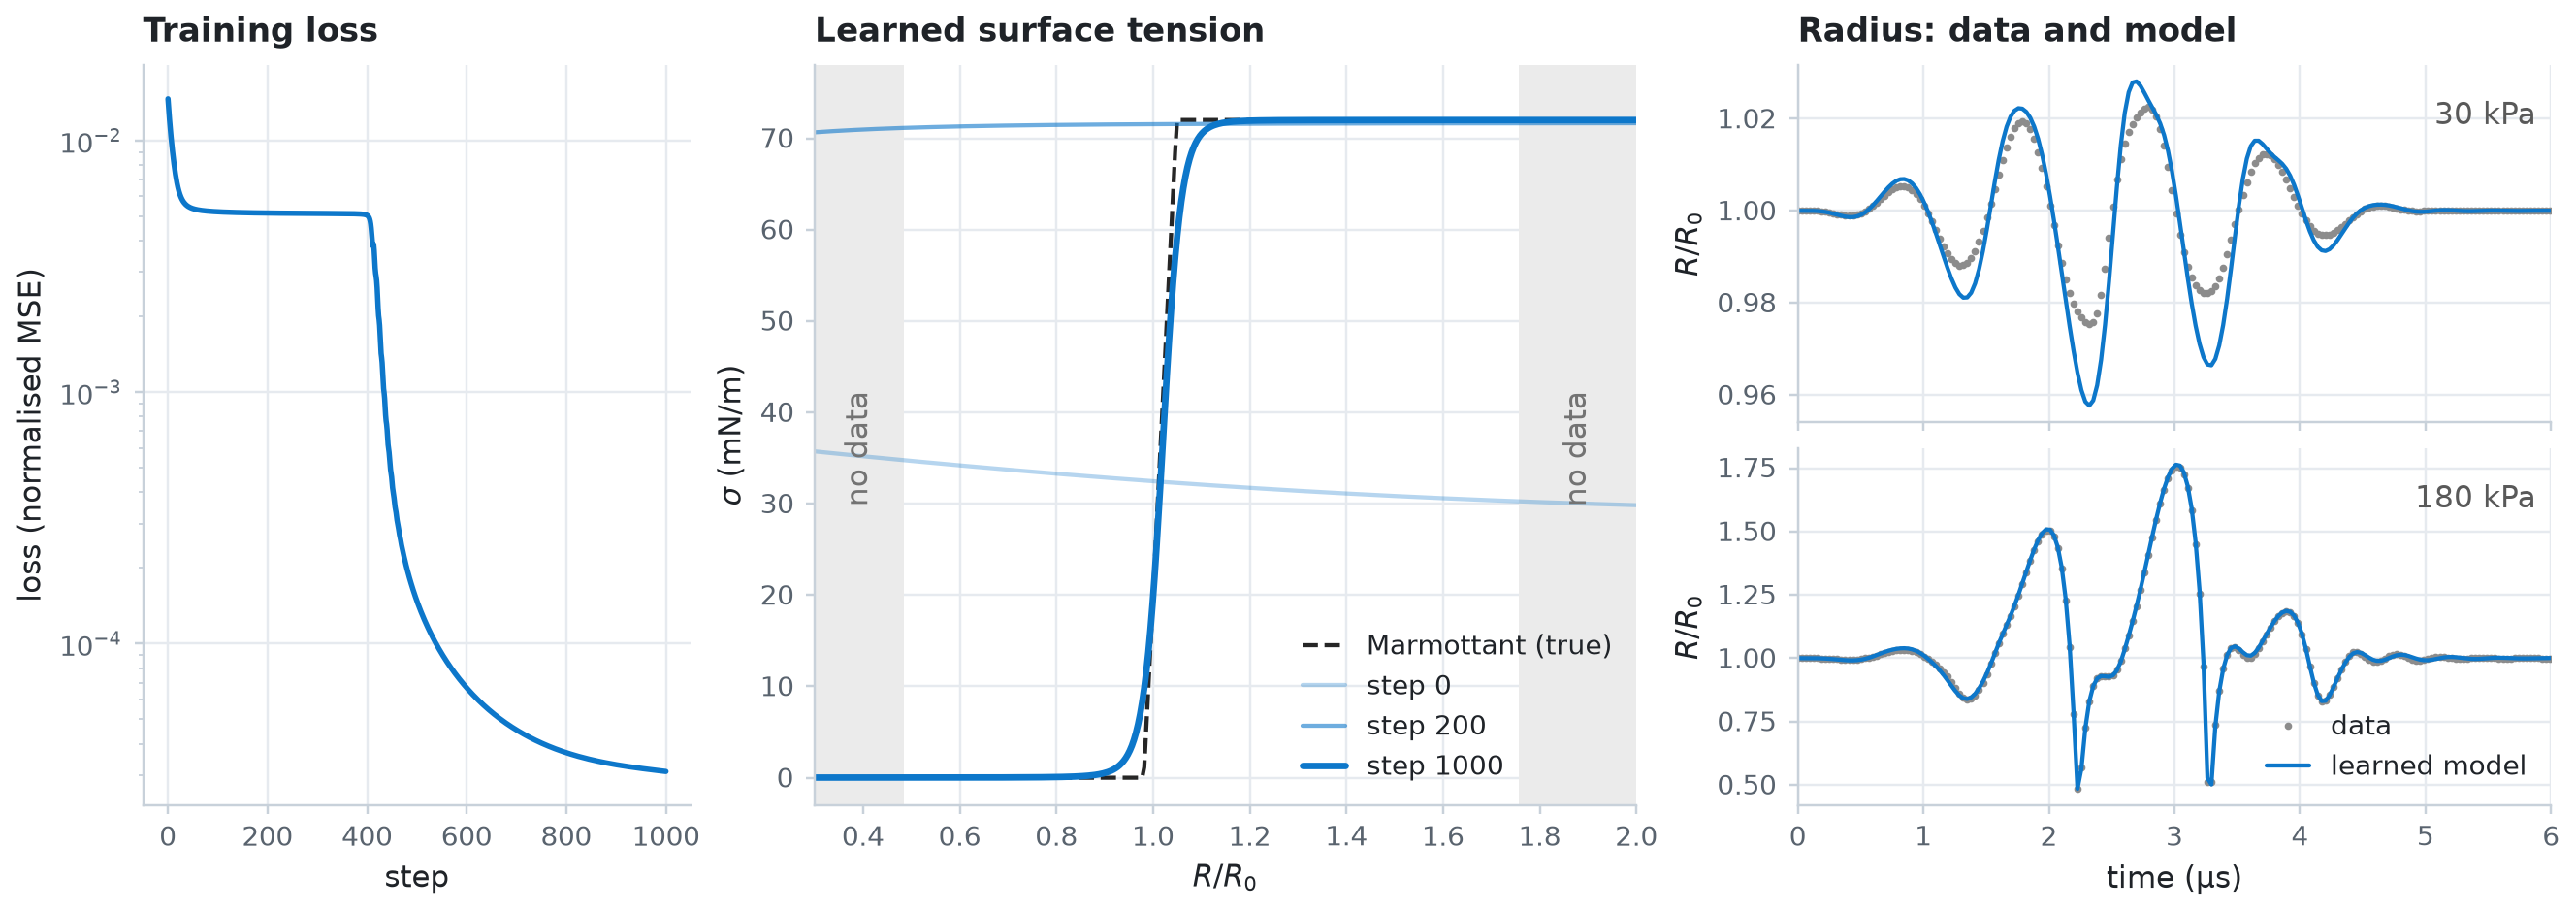

In [6]:
fig = plt.figure(figsize=(12, 4.2))
grid = fig.add_gridspec(2, 3, width_ratios=[0.8, 1.2, 1.1])
ax_loss = fig.add_subplot(grid[:, 0])
ax_sigma = fig.add_subplot(grid[:, 1])
ax_low = fig.add_subplot(grid[0, 2])
ax_high = fig.add_subplot(grid[1, 2], sharex=ax_low)

ax_loss.semilogy(fit.loss_history, color="C0")
ax_loss.set_xlabel("step")
ax_loss.set_ylabel("loss (normalised MSE)")
ax_loss.set_title("Training loss")

# Outside the recorded range, the network extrapolates freely.
for lo, hi in ((float(x[0]), x_lo), (x_hi, float(x[-1]))):
    ax_sigma.axvspan(lo, hi, color="0.92", lw=0)
    ax_sigma.text(
        (lo + hi) / 2,
        36,
        "no data",
        rotation=90,
        ha="center",
        va="center",
        color="0.45",
    )
ax_sigma.plot(x, sigma_true, color="0.15", lw=1.4, ls="--", label="Marmottant (true)")
for step, alpha in zip(snapshot_steps[:-1], (0.3, 0.6), strict=True):
    ax_sigma.plot(
        x,
        evaluate(snapshots[step]),
        color="C0",
        lw=1.4,
        alpha=alpha,
        label=f"step {step}",
    )
ax_sigma.plot(x, sigma_learned, color="C0", lw=2.2, label=f"step {N_STEPS}")
ax_sigma.set_xlim(float(x[0]), float(x[-1]))
ax_sigma.set_ylim(-3, 1e3 * SIGMA_MAX + 6)
ax_sigma.set_xlabel(r"$R/R_0$")
ax_sigma.set_ylabel(r"$\sigma$ (mN/m)")
ax_sigma.set_title("Learned surface tension")
ax_sigma.legend(loc="lower right")

for ax, index in ((ax_low, 0), (ax_high, len(PRESSURES) - 1)):
    condition, result = conditions[index], fit.result[index]
    ax.plot(ts_us, condition["radius"] / R0, ".", ms=3, color="0.55", label="data")
    ax.plot(ts_us, result.radius / R0, color="C0", lw=1.4, label="learned model")
    ax.set_ylabel(r"$R/R_0$")
    ax.text(
        0.98,
        0.9,
        f"{condition['pressure'] / 1e3:.0f} kPa",
        transform=ax.transAxes,
        ha="right",
        va="top",
        color="0.35",
    )
ax_low.set_title("Radius: data and model")
ax_low.tick_params(labelbottom=False)
ax_low.set_xlim(0, 6)
ax_high.legend(loc="lower right")
ax_high.set_xlabel("time (µs)")
plt.show()

For the first few hundred steps, the loss sits on a plateau. The network first settles on a nearly constant surface tension close to $\sigma_\text{max}$, the best that a flat law can do. Once it bends the curve near $R_0$, the loss falls by two orders of magnitude.

Within the recorded range, the network reproduces the three regimes: zero tension when the shell buckles, a steep elastic rise near $R_0$, and the tension of clean water once the shell ruptures. The lowest pressure is the hardest recording to match, because there the radius depends mostly on the slope of $\sigma$ near $R_0$, the shell elasticity. More training steps tighten it; see `N_STEPS` at the top of the example.

Outside the recorded range, the data say nothing, so the network's values there are a guess. Here, the saturated sigmoid happens to continue the right trend, but nothing guarantees it. Record at the amplitudes where you want to know the law.

To turn the learned curve into numbers, such as the buckling radius or the elasticity, fit a parametric law to it, or fit that law to the data directly, as in example 10. For more on neural laws, failed trial steps, and solver settings for training, see the [fitting guide](https://imperial-nsb.github.io/jbubble/guide/fitting/).